# Project Objective

The objective of this project is to analyze customer churn patterns, identify the factors contributing to customer attrition, and provide actionable business recommendations to improve customer retention and reduce revenue loss.

In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [37]:
df=pd.read_csv("C:/Users/Ritik Pandey/OneDrive/Desktop/Telco Customer Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [38]:
# Checking haed and tail of data

In [39]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [40]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [42]:
#Checking the Data Type and value missing

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [44]:
# Change the data tyle of  Total Charges

In [45]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce") # Coerce will replace the error to NaN

In [47]:
df["TotalCharges"].dtype

dtype('float64')

In [48]:
#Feature Engineering 

In [50]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [56]:
df["ChurnFlag"]=np.where(df["Churn"]=="Yes",1,0) #Creating New Column If user Churn =1 if user still active then 0

In [57]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1


In [59]:
#Analysis

In [ ]:
#Churn Rate

In [77]:
Churn_Rate=(df["ChurnFlag"]).mean()*100

In [78]:
Churn_Rate= round(Churn_Rate,2)
print(Churn_Rate,"%")

26.54 %


Overall churn rate is 26.54%.
This means 26.54% of customers have stopped using the company's services.

In [79]:
# Retention Rate

In [81]:
Retention_Rate=100-Churn_Rate
print(round(Retention_Rate,2),"%")

73.46 %


The customer retention rate is 73.46%.
This indicates that nearly three out of four customers continue using the company's services.

In [82]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [83]:
#Churn by Internet Service

In [90]:
Churn_by_Service=(df.groupby("InternetService")["ChurnFlag"].mean().mul(100).round(2)).reset_index(name="Churn Rate(%)")
print(Churn_by_Service)

  InternetService  Churn Rate(%)
0             DSL          18.96
1     Fiber optic          41.89
2              No           7.40


Customers using Fiber Optic internet have the highest churn rate (41.89%).

This suggests that Fiber Optic customers are more likely to leave the service than DSL or customers with no internet service.

In [91]:
# Churn By Contract Type

In [93]:
Churn_by_Contract=(df.groupby("Contract")["ChurnFlag"].mean().mul(100).round(2)).reset_index(name="Churn Rate(%)")
print(Churn_by_Contract)

         Contract  Churn Rate(%)
0  Month-to-month          42.71
1        One year          11.27
2        Two year           2.83


Customers with Month-to-month contracts have the highest churn rate (42.71%).
Customers with One-year contracts have a much lower churn rate (11.27%).

In [94]:
# Revenue Loss by Contract Type

In [107]:
Revenue_at_Risk=(df[df["ChurnFlag"]==1]).groupby("Contract")["TotalCharges"].sum().reset_index(name="Revenue at Risk")
print(Revenue_at_Risk)

         Contract  Revenue at Risk
0  Month-to-month       1927182.25
1        One year        674991.20
2        Two year        260753.45


Customers on Month-to-month contracts account for the highest revenue at risk (₹1,927,182.75).
Revenue at risk is significantly lower for One-year and Two-year contracts.

In [193]:
# Average revenue per user (ARPU)

In [102]:
arpu=df["TotalCharges"].mean()
print("ARPU=", arpu)

ARPU= 2283.3004408418656


Average revenue per user is Rs.2283.3

In [105]:
Revenue_Loss=df.groupby("Contract").agg(
    Customer=("customerID","count"),
    Revenue=("TotalCharges","sum"),
    ChurRate=("ChurnFlag","mean")
).reset_index()
print(Revenue_Loss)

         Contract  Customer    Revenue  ChurRate
0  Month-to-month      3875  5305861.5  0.427097
1        One year      1473  4467053.5  0.112695
2        Two year      1695  6283253.7  0.028319


In [108]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'ChurnFlag'],
      dtype='object')

In [110]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No,0


In [111]:
# Visualization

In [115]:
df_visual=df.copy()

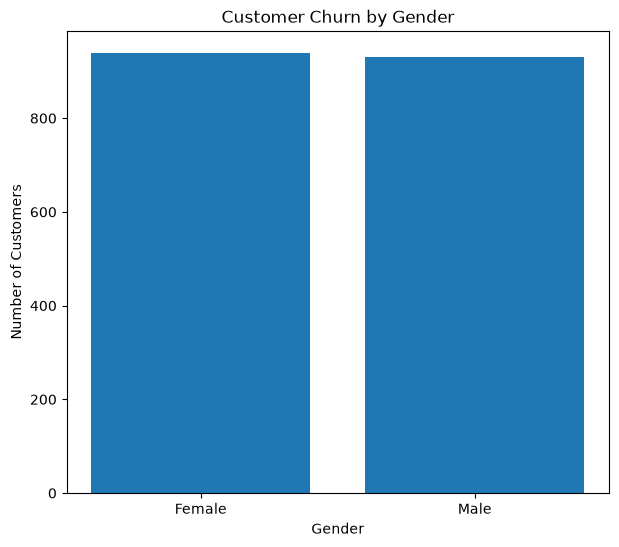

In [135]:
churn_gender=df_visual[df_visual["ChurnFlag"]==1].groupby("gender").size()
plt.figure(figsize=(7,6))
plt.bar(churn_gender.index,churn_gender.values)
plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()


Male and female customers show a similar number of churned customers.

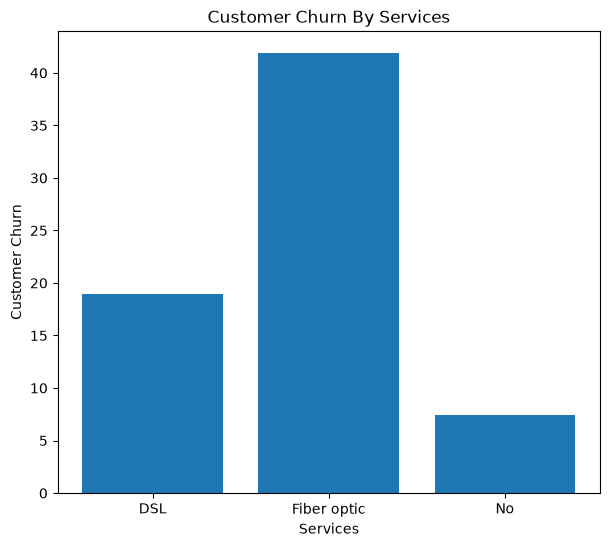

In [199]:
Churn_by_InternetServices=df_visual.groupby("InternetService")["ChurnFlag"].mean().mul(100).round(2)
plt.figure(figsize=(7,6))
plt.bar(Churn_by_InternetServices.index,Churn_by_InternetServices.values)
plt.title("Customer Churn By Services")
plt.xlabel("Services")
plt.ylabel("Customer Churn")
plt.show()


In [154]:
df_visual.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'ChurnFlag'],
      dtype='object')

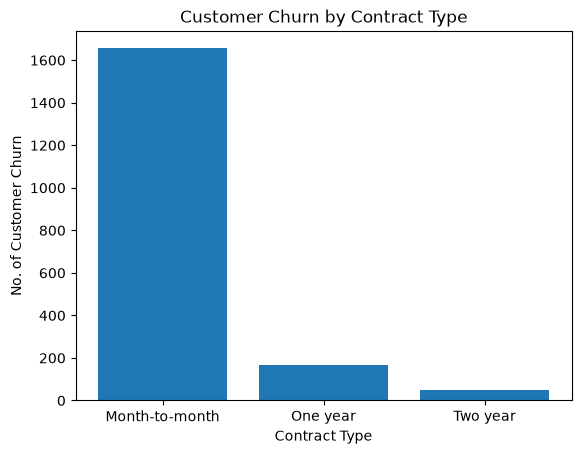

In [197]:
chun_contrct=df_visual.groupby("Contract")["ChurnFlag"].sum()
plt.bar(chun_contrct.index,chun_contrct.values)
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("No. of Customer Churn")
plt.show()

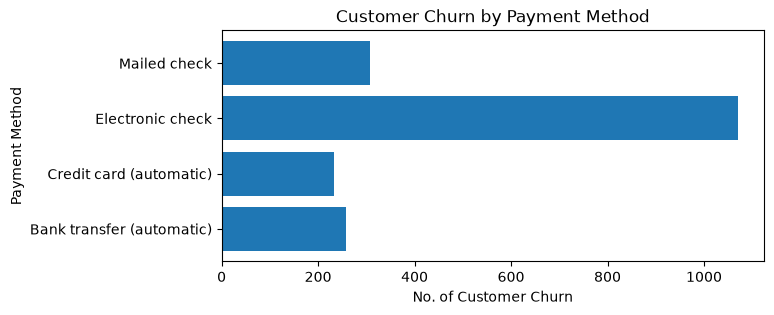

In [201]:
Churn_Payment=df_visual.groupby("PaymentMethod")["ChurnFlag"].sum()
plt.figure(figsize=(7,3))
plt.barh(Churn_Payment.index,Churn_Payment.values)
plt.title("Customer Churn by Payment Method")
plt.xlabel("No. of Customer Churn")
plt.ylabel("Payment Method")
plt.show()

Customers using Electronic Check have the highest number of churned customers.

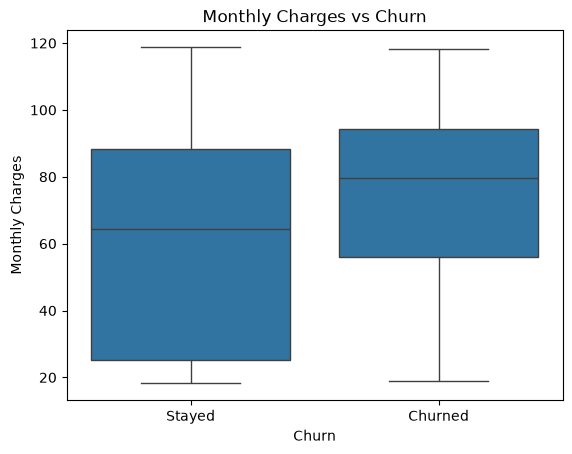

In [203]:
sns.boxplot(x="ChurnFlag",y="MonthlyCharges", data=df_visual)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.xticks([0, 1], ["Stayed", "Churned"])
plt.show()

Customers who churn generally have higher monthly charges than customers who stay.

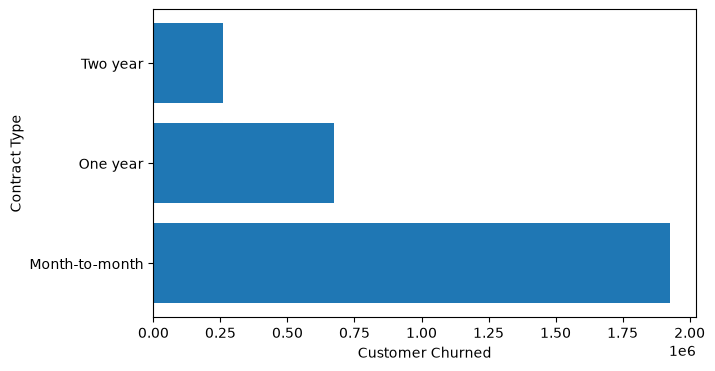

In [185]:
revenue_at_risk=df_visual[df_visual["ChurnFlag"]==1].groupby("Contract")["TotalCharges"].sum().round(2)
plt.figure(figsize=(7,4))
plt.barh(revenue_at_risk.index,revenue_at_risk.values)
plt.ylabel("Contract Type")
plt.xlabel("Customer Churned")
plt.show()

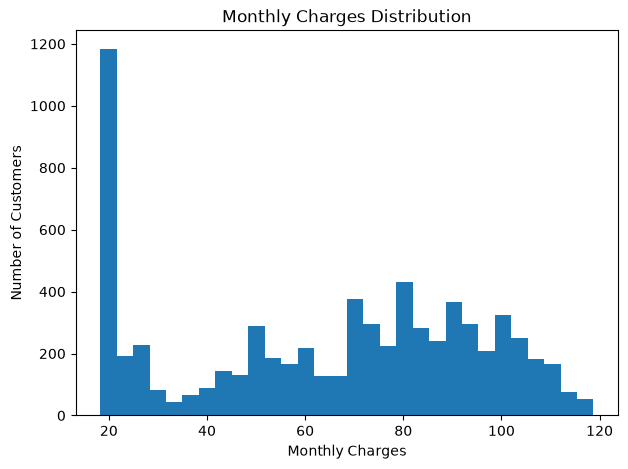

In [205]:
plt.figure(figsize=(7,5))

plt.hist(
    df_visual["MonthlyCharges"],
    bins=30,
    
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

# Final Summary

## Key Findings

• Overall churn rate is 26.54%.

• Month-to-month customers have the highest churn rate.

• Fiber Optic customers are more likely to churn than DSL customers.

• Electronic Check users have the highest churn count.

• Customers paying higher monthly charges are more likely to churn.

• Most revenue at risk comes from Month-to-month customers.

## Business Recommendations

• Encourage customers to switch to long-term contracts.

• Investigate why Fiber Optic customers churn more.

• Improve the payment experience for Electronic Check users.

• Offer loyalty discounts to high-value Month-to-month customers.
